In [1]:
import pandas as pd 
import torch
import numpy as np
import random
import os
from matplotlib import pyplot as plt

def set_seed(seed: int = 42) -> None:
    """Sets the random seed for reproducibility across PyTorch, NumPy, and Python's random module."""
    os.environ['PYTHONHASHSEED'] = str(seed)  # For Python's hash seed
    torch.manual_seed(seed)  # For PyTorch's CPU and CUDA RNGs
    torch.cuda.manual_seed(seed)  # For CUDA devices specifically
    torch.cuda.manual_seed_all(seed) # For all CUDA devices if multiple are used
    np.random.seed(seed)  # For NumPy's random number generator
    random.seed(seed)  # For Python's built-in random module

    # For deterministic algorithms in PyTorch (optional, but recommended for full reproducibility)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Example usage:
set_seed(123)

In [2]:
import sys
import os

# Add project root (parent of "src") to Python path
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_OhioT1DM, load_OhioT1DM_patient_split

Ohio_PATH = "..\data\\raw\\" 
data = load_OhioT1DM_patient_split(path=Ohio_PATH, look_back=128)

In [17]:
X_train, X_val, X_test, y_reg_train, y_reg_val, y_reg_test, y_clf_train, y_clf_val, y_clf_test = data

In [27]:
y_clf_test.shape

(20647,)

In [2]:
import sys
import os

# Add project root (parent of "src") to Python path
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_OhioT1DM

Ohio_PATH = "..\data\\raw\\"
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = load_OhioT1DM(path=Ohio_PATH, look_back=128, test_size = None)
X_test, y_reg_test, y_clf_test = load_OhioT1DM(path=Ohio_PATH, look_back=128, train=False)

In [3]:
import glob 
import re

generated_PATH = "..\data\\generated\\synth_**.pt"

generated_paths  = glob.glob(generated_PATH) 

pattern = r"synth_(\w+)\.pt"  # capture word characters between 'synth_' and '.pt'

generated_data = {}

for path in generated_paths: 
    
    data = torch.load(path, weights_only=False)
    file_name = path.split("\\")[-1]
    match = re.search(pattern, file_name)
    generator = match.group(1)
    data = data.clip(40, 400)
    generated_data[generator] = np.array(data.detach().cpu()).reshape(-1, 128)
        
    print(f"synth data generated by {generator} loaded: {file_name} .")



synth data generated by ddpm loaded: synth_ddpm.pt .
synth data generated by gan loaded: synth_gan.pt .
synth data generated by nf loaded: synth_nf.pt .
synth data generated by vae loaded: synth_vae.pt .


In [4]:
MIN = 40
MAX = 400 

function_reverse = lambda t: (t / 2 + 0.5) * (MAX - MIN) + MIN 

In [5]:
Evaluation_results = {} 

Evaluation_results ["StatisticalFidelity"] = {}

In [6]:
X = np.concatenate([X_train, X_val])

## Statistical Fidelity

Higher-Order Statistics: Compare overall behavior

In [7]:
from scipy.stats import skew, kurtosis

x = X_val

Evaluation_results ["StatisticalFidelity"]["HighOredeStats"] = {"Criterions" : ["mean", "std", "skew", "kurtosis"]}
summary = lambda x: [np.mean(x), np.std(x), skew(x), kurtosis(x)]
Evaluation_results ["StatisticalFidelity"]["HighOredeStats"]["OhioT1dm"] = summary(x.ravel())

for model, data in generated_data.items(): 
    
    Evaluation_results ["StatisticalFidelity"]["HighOredeStats"][model] = summary(data[:len(x)].ravel())
    print(f"\n{model}")
    print("Real:", summary(x.ravel()))
    print("Synth:", summary(data.ravel()))



ddpm
Real: [163.78052, 59.03084, 0.7934173874295467, 0.9213082591831165]
Synth: [176.87314, 63.278816, 0.3845819068068395, -0.1342964235724602]

gan
Real: [163.78052, 59.03084, 0.7934173874295467, 0.9213082591831165]
Synth: [161.04118, 58.336807, 0.6685833186166897, 0.2499627375904856]

nf
Real: [163.78052, 59.03084, 0.7934173874295467, 0.9213082591831165]
Synth: [167.26617, 65.298836, 0.7383798292789239, 0.7247804486136529]

vae
Real: [163.78052, 59.03084, 0.7934173874295467, 0.9213082591831165]
Synth: [125.87941, 10.491634, 0.2101889192119734, -0.03080852740087492]


In [13]:
x.shape


(16870, 128)

Marginal Distribution Comparison: Compare glucose range/shape

In [8]:
from scipy.stats import ks_2samp
import numpy as np

Evaluation_results ["StatisticalFidelity"]["KS_Test"] = {"Criterions" : ["ks_stat", "p_val"]}


for model, data in generated_data.items(): 
    
    ks_stat, p_val = ks_2samp(x.ravel(), data[:len(x)].ravel())
    Evaluation_results ["StatisticalFidelity"]["KS_Test"][model] = [ks_stat, p_val]
    print(f"KS statistic {model} = {ks_stat:.4f}, p-value = {p_val:.4f}")

KS statistic ddpm = 0.1174, p-value = 0.0000
KS statistic gan = 0.0417, p-value = 0.0000
KS statistic nf = 0.0385, p-value = 0.0000
KS statistic vae = 0.5490, p-value = 0.0000


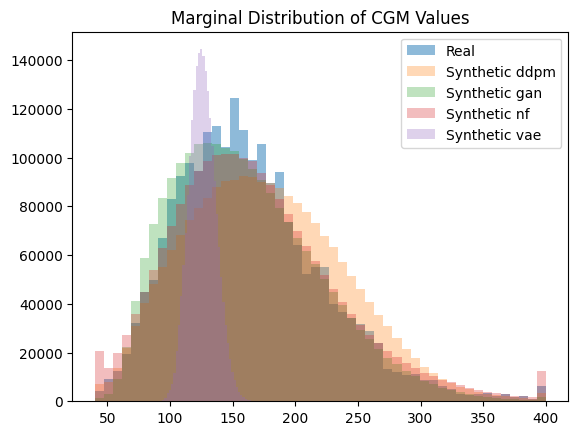

In [9]:
import matplotlib.pyplot as plt

plt.hist(x.ravel(), bins=50, alpha=0.5, label="Real")
for model, data in generated_data.items(): 
    plt.hist(data[:len(x)].ravel(), bins=50, alpha=0.3, label=f"Synthetic {model}")
plt.legend(); plt.title("Marginal Distribution of CGM Values")
plt.show()


Temporal Dependence (Dynamics): Check lag dependencies

ACF difference ddpm: 0.2135
ACF difference gan: 0.4142
ACF difference nf: 0.0430
ACF difference vae: 1.8426


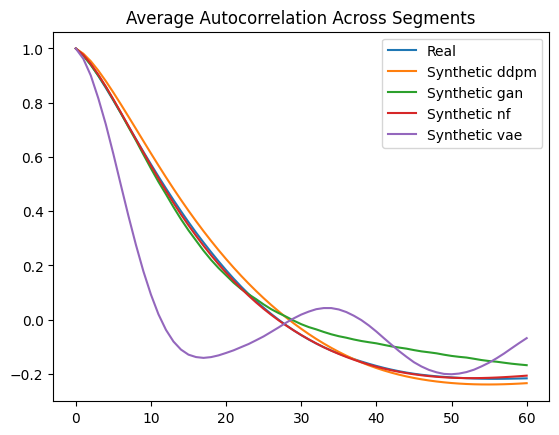

In [10]:
from statsmodels.tsa.stattools import acf

Evaluation_results ["StatisticalFidelity"]["TemporalDependence"] = {"Criterions" : ["acf_diff"]}

def mean_acf(X, nlags=60):
    acfs = []
    for row in X:
        acfs.append(acf(row, nlags=nlags))
    return np.mean(acfs, axis=0)

acf_real = mean_acf(x)
plt.plot(acf_real, label="Real")

for model, data in generated_data.items(): 
    acf_synth = mean_acf(data[:len(x)])
    acf_diff = np.linalg.norm(acf_real - acf_synth)
    Evaluation_results ["StatisticalFidelity"]["TemporalDependence"][model] = [acf_diff]
    print(f"ACF difference {model}: {acf_diff:.4f}")
    plt.plot(acf_synth, label=f"Synthetic {model}")



plt.legend(); plt.title("Average Autocorrelation Across Segments")
plt.show()


Spectral Properties (Frequency Domain): Compare periodicity

PSD difference ddpm: 20191.0996
PSD difference gan: 27968.2383
PSD difference nf: 9292.4355
PSD difference vae: 134449.3438


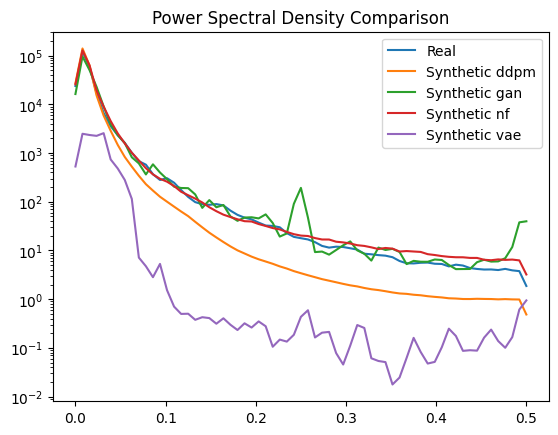

In [12]:
from scipy.signal import welch

Evaluation_results ["StatisticalFidelity"]["SpectralProperties"] = {"Criterions" : ["PSD_diff"]}

f_real, Pxx_real = welch(x, nperseg=128)
plt.semilogy(f_real, Pxx_real.mean(axis=0), label='Real') 
psd_real = Pxx_real.mean(axis=0).ravel()

for model, data in generated_data.items(): 
    f_synth, Pxx_synth = welch(data[:len(x)], nperseg=128)
    psd_synth = Pxx_synth.mean(axis=0).ravel()
    psd_diff = np.linalg.norm(psd_real - psd_synth) 
    Evaluation_results ["StatisticalFidelity"]["SpectralProperties"][model] = [psd_diff]
    print(f"PSD difference {model}: {psd_diff:.4f}")
    plt.semilogy(f_synth, psd_synth, label=f'Synthetic {model}')
    

plt.legend(); plt.title("Power Spectral Density Comparison")
plt.show()


In [12]:
Evaluation_results

{'StatisticalFidelity': {'HighOredeStats': {'Criterions': ['mean',
    'std',
    'skew',
    'kurtosis'],
   'OhioT1dm': [157.63489, 58.019825, 0.6058438155968802, 0.16030767680529756],
   'ddpm': [176.87314, 63.278816, 0.3845819068068395, -0.1342964235724602],
   'gan': [161.04118, 58.336807, 0.6685833186166897, 0.2499627375904856],
   'nf': [167.26617, 65.298836, 0.7383798292789239, 0.7247804486136529],
   'vae': [125.87941, 10.491634, 0.2101889192119734, -0.03080852740087492]},
  'KS_Test': {'Criterions': ['ks_stat', 'p_val'],
   'ddpm': [0.1403599791410407, 0.0],
   'gan': [0.02521924137113385, 0.0],
   'nf': [0.06089389717977978, 0.0],
   'vae': [0.5022396520295804, 0.0]},
  'TemporalDependence': {'Criterions': ['acf_diff'],
   'ddpm': [0.3126958536817439],
   'gan': [0.3865179625901892],
   'nf': [0.09116655165836414],
   'vae': [1.7539589369644548]},
  'SpectralProperties': {'Criterions': ['PSD_diff'],
   'ddpm': [32729.254],
   'gan': [15867.939],
   'nf': [21202.797],
   'vae

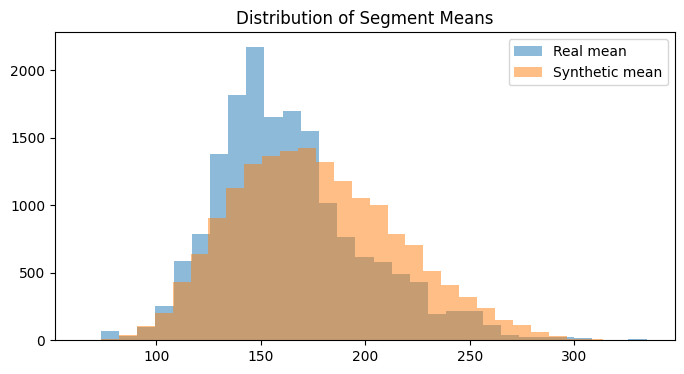

KS mean=0.172, KS var=0.071
p_value mean=0.000, p_value var=0.000


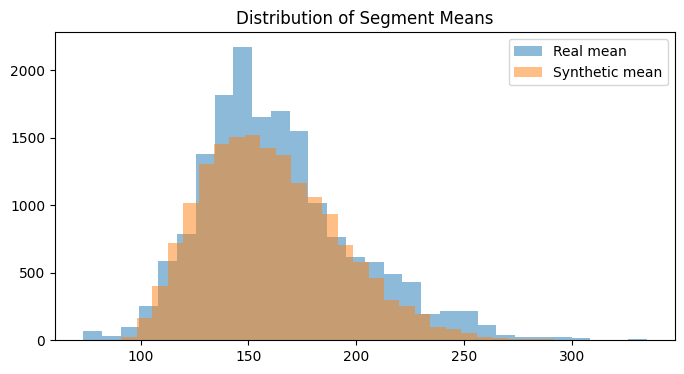

KS mean=0.044, KS var=0.078
p_value mean=0.000, p_value var=0.000


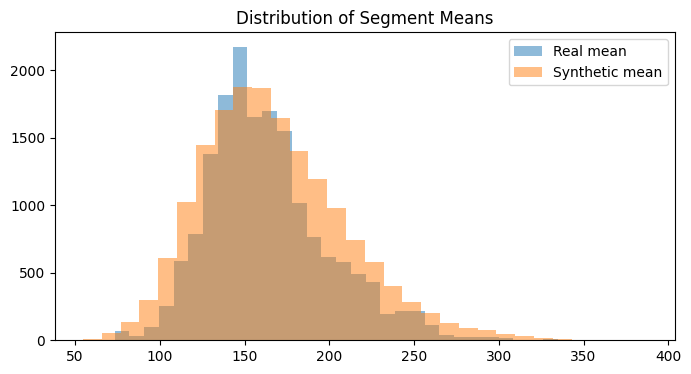

KS mean=0.078, KS var=0.056
p_value mean=0.000, p_value var=0.000


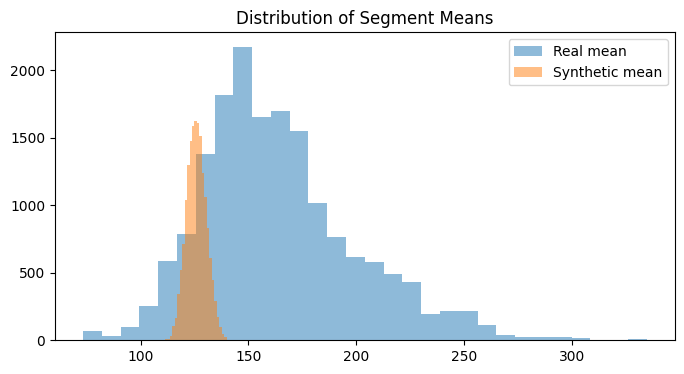

KS mean=0.781, KS var=0.989
p_value mean=0.000, p_value var=0.000


In [15]:
for model, data in generated_data.items():   
    mean_real = x.mean(axis=1)
    mean_synth = data[:len(x)].mean(axis=1)

    var_real = x.var(axis=1)
    var_synth = data[:len(x)].var(axis=1)

    plt.figure(figsize=(8,4))
    plt.hist(mean_real, bins=30, alpha=0.5, label="Real mean")
    plt.hist(mean_synth, bins=30, alpha=0.5, label="Synthetic mean")
    plt.legend(); plt.title("Distribution of Segment Means")
    plt.show()

    ks_mean, p_mean = ks_2samp(mean_real, mean_synth)
    ks_var, p_var  = ks_2samp(var_real, var_synth)
    print(f"KS mean={ks_mean:.3f}, KS var={ks_var:.3f}")
    print(f"p_value mean={p_mean:.3f}, p_value var={p_var:.3f}")


## Diversity

coverage ratio using FrechetDistance (FID) and UMAP (GANsTrained by a Two Time-Scale Update Rule
 Converge to a Local Nash Equilibrium, Improved Precision and Recall Metric for Assessing Generative Models)

c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding trustworthiness: 0.685
⚠️ Warning: UMAP may be distorting structure. Consider tuning parameters.
FID-like diversity score ddpm: 26631.611
Prec-Recl in Umap Space ddpm: 0.913, 0.841


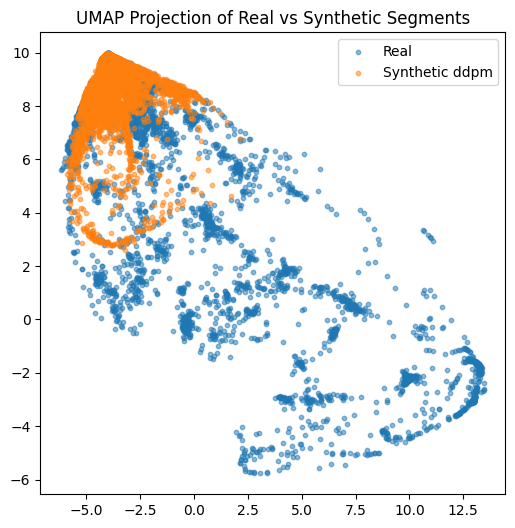

FID-like diversity score gan: 41479.143
Prec-Recl in Umap Space gan: 0.930, 0.831


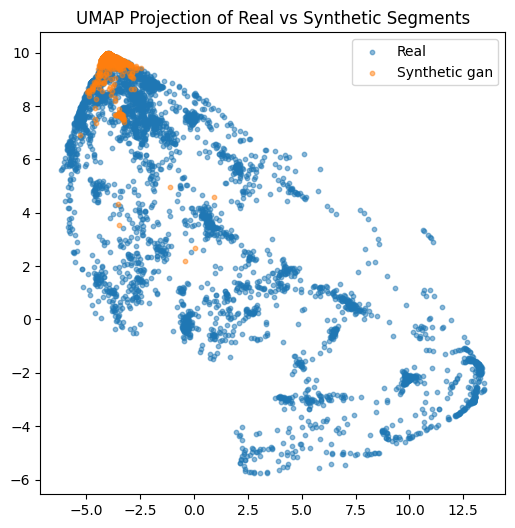

ValueError: Input X contains NaN.
NearestNeighbors does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

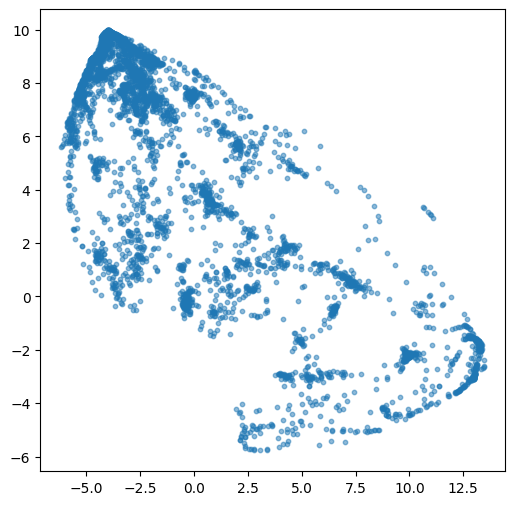

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from scipy.spatial.distance import cdist
from sklearn.manifold import trustworthiness

Evaluation_results ["Diversity"] = {"Criterions" : ["FID", "Precision", "Recall"]}

def frechet_distance(X, Y):
    mu_x, mu_y = X.mean(0), Y.mean(0)
    cov_x, cov_y = np.cov(X, rowvar=False), np.cov(Y, rowvar=False)
    covmean = sqrtm(cov_x.dot(cov_y)).real
    return np.sum((mu_x - mu_y)**2) + np.trace(cov_x + cov_y - 2*covmean)

# Step 1: PCA (retain most variance)
pca = PCA(n_components=0.95)
pca.fit(X_train)
real_pca = pca.transform(x)
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.0, metric='euclidean', random_state=42, n_epochs=500)
umap_model.fit(X_train)
real_umap = umap_model.transform(real_pca) 

# Step 3: Verify stability
trust_score = trustworthiness(real_pca, real_umap, n_neighbors=12)
print(f"Embedding trustworthiness: {trust_score:.3f}")
if trust_score < 0.8:
    print("⚠️ Warning: UMAP may be distorting structure. Consider tuning parameters.")

#-------------------
# Tune of threshold
#-------------------

def coverage_ratio_func(X_real, X_synth, threshold=0.1):
    """
    Calculate what fraction of real samples are covered by synthetic samples.
    
    Args:
        X_real: Real data points (N x D)
        X_synth: Synthetic data points (M x D)
        threshold: Distance threshold for "coverage"
    
    Returns:
        Fraction of real samples with at least one synthetic neighbor within threshold
    """
    coverage = np.mean([
        np.min(np.linalg.norm(X_synth - r[None, :], axis=-1)) < threshold
        for r in X_real
    ])
    return coverage

def precision_recall_kynkaanniemi(X_real, X_synth, k=3):
    """
    Standard Precision-Recall for distributions.
    
    Most cited implementation: Kynkäänniemi et al., NeurIPS 2019
    "Improved Precision and Recall Metric for Assessing Generative Models"
    
    Uses k-th NN distance as LOCAL threshold (adapts to density)
    """
    from sklearn.neighbors import NearestNeighbors
    
    # Build k-NN models
    # k+1 because first neighbor is the point itself
    nbrs_real = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_real)
    nbrs_synth = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_synth)
    
    # === STEP 1: Define "manifolds" using k-th NN distance ===
    # For each real point, find its k-th nearest neighbor
    real_distances, _ = nbrs_real.kneighbors(X_real)
    real_radii = real_distances[:, k]  # k-th column = k-th NN distance
    
    # For each synth point, find its k-th nearest neighbor
    synth_distances, _ = nbrs_synth.kneighbors(X_synth)
    synth_radii = synth_distances[:, k]
    
    # === STEP 2: Precision ===
    # For each synthetic sample, find nearest real sample
    synth_to_real_dist, synth_to_real_idx = nbrs_real.kneighbors(X_synth, n_neighbors=1)
    synth_to_real_dist = synth_to_real_dist.flatten()
    synth_to_real_idx = synth_to_real_idx.flatten()
    
    # A synth sample has good "precision" if it's within the real manifold
    # i.e., distance to nearest real < that real point's k-th NN radius
    precision = np.mean(synth_to_real_dist < real_radii[synth_to_real_idx])
    
    # === STEP 3: Recall (Coverage) ===
    # For each real sample, find nearest synthetic sample
    real_to_synth_dist, real_to_synth_idx = nbrs_synth.kneighbors(X_real, n_neighbors=1)
    real_to_synth_dist = real_to_synth_dist.flatten()
    real_to_synth_idx = real_to_synth_idx.flatten()
    
    # A real sample is "covered" if it's within the synthetic manifold
    # i.e., distance to nearest synth < that synth point's k-th NN radius
    recall = np.mean(real_to_synth_dist < synth_radii[real_to_synth_idx])
    
    return precision, recall

# # Calculate pairwise distances in real data
# real_distances = cdist(real_umap[:7500], real_umap[:7500])

# # Remove diagonal (distance to self = 0)
# real_distances_no_diag = real_distances[~np.eye(real_distances.shape[0], dtype=bool)]

# # Use a percentile as threshold (e.g., 5th or 10th percentile)
# threshold_5 = np.percentile(real_distances_no_diag, 5)
# print(f"Suggested threshold (5th percentile): {threshold_5:.4f}")

# # Or use nearest neighbor distance
# nearest_neighbor_distances = np.partition(real_distances, 1, axis=1)[:, 1]
# threshold = np.percentile(nearest_neighbor_distances, 10)
# print(f"Suggested threshold (10th %ile of NN): {threshold:.4f}")

# # Visualization
# plt.figure(figsize=(6,6))
# plt.scatter(real_umap[:,0], real_umap[:,1], s=10, alpha=0.5, label="Real")

for model, data in generated_data.items(): 
    # Visualization
    plt.figure(figsize=(6,6))
    plt.scatter(real_umap[:,0], real_umap[:,1], s=10, alpha=0.5, label="Real")
    synth_pca = pca.transform(data[:len(x)])
    # Step 2: UMAP (for nonlinear manifold)
    synth_umap = umap_model.transform(synth_pca) 
    
    fid_score = frechet_distance(real_pca, synth_pca)
    
    precision, recall = precision_recall_kynkaanniemi(real_umap, synth_umap, k=3)
    
    #coverage_ratio = coverage_ratio_func(real_umap, synth_umap, threshold=0.1)
    Evaluation_results ["Diversity"][model] = [fid_score, precision, recall]
    print(f"FID-like diversity score {model}: {fid_score:.3f}")
    print(f"Prec-Recl in Umap Space {model}: {precision:.3f}, {recall:.3f}")
    
    plt.scatter(synth_umap[:,0], synth_umap[:,1], s=10, alpha=0.5, label=f"Synthetic {model}")
    
    plt.legend(); plt.title("UMAP Projection of Real vs Synthetic Segments")
    plt.show()


In [ ]:
np.sum(np.isn(synth_pca))

0

## Privacy

Nearest-Neighbor Similarity Test

In [16]:
Evaluation_results ["Privacy"] = {}

c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


Avg nearest neighbor distance RR: 59.014 ± 22.740


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


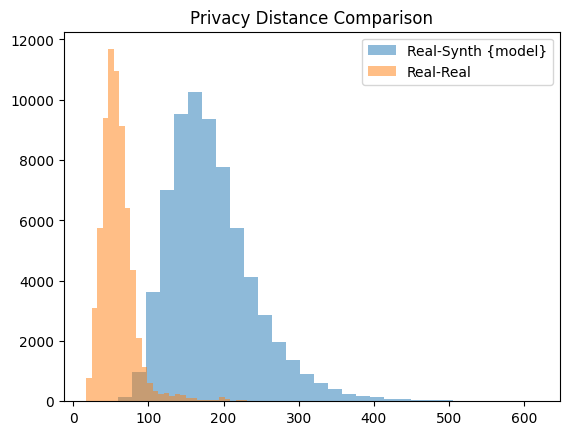

Avg nearest neighbor distance ddpm: 185.136 ± 58.017
✅ Synthetic samples are sufficiently distinct


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


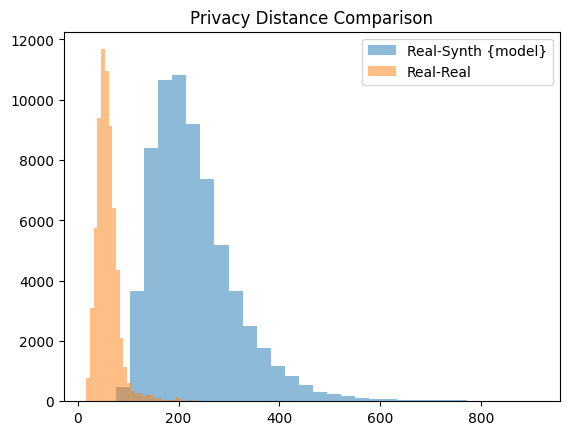

Avg nearest neighbor distance gan: 231.860 ± 86.260
✅ Synthetic samples are sufficiently distinct


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


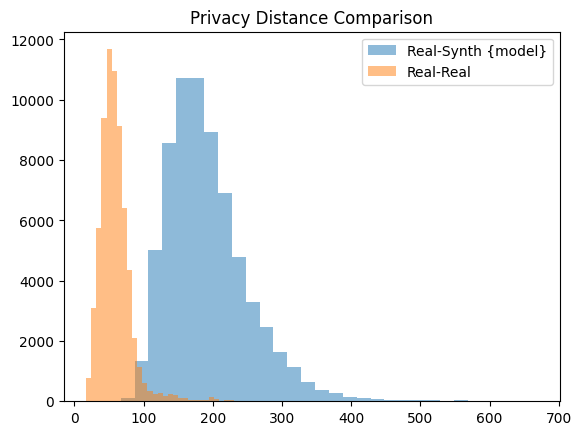

Avg nearest neighbor distance nf: 192.357 ± 59.492
✅ Synthetic samples are sufficiently distinct


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


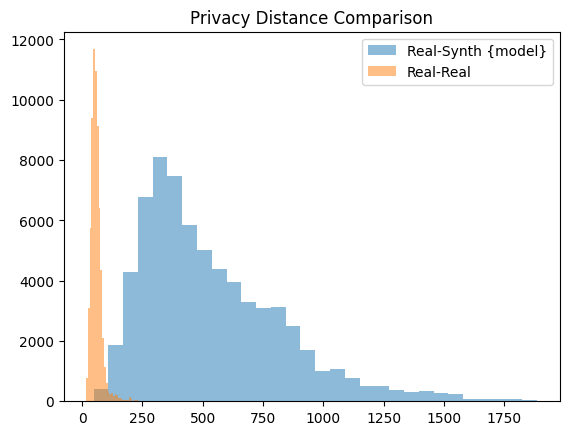

Avg nearest neighbor distance vae: 539.135 ± 294.525
✅ Synthetic samples are sufficiently distinct


In [17]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

Evaluation_results ["Privacy"]["NN Similarity test"] = {"Criterions" : ["AvgNN", "StdNN"]}

diff = 0.3

# def nearest_neighbor_distance(real, synth):
#     D = euclidean_distances(synth, real)
#     nearest_dist = D.min(axis=1)  # closest real to each synthetic
#     return nearest_dist.mean(), nearest_dist.std()

def nearest_neighbor_distance(X, Y=None):
    if Y is None:
        Y = X
        same_set = True
    else:
        same_set = False

    D = euclidean_distances(X, Y)
    
    # If comparing the same set, ignore self-distances
    if same_set:
        np.fill_diagonal(D, np.inf)
    
    nearest_dist = D.min(axis=1)
    return nearest_dist.mean(), nearest_dist.std(), nearest_dist

rr_mean, rr_std, rr_nearest = nearest_neighbor_distance(X_train, None) 
Evaluation_results ["Privacy"]["NN Similarity test"]["Self"] = [rr_mean, rr_std]
print(f"Avg nearest neighbor distance RR: {rr_mean:.3f} ± {rr_std:.3f}")


for model, data in generated_data.items(): 
    mean_d, std_d, nearest_d = nearest_neighbor_distance(X_train, data)
    Evaluation_results ["Privacy"]["NN Similarity test"][model] = [mean_d, std_d]
    plt.hist(nearest_d, bins=30, alpha=0.5, label='Real-Synth {model}')
    plt.hist(rr_nearest, bins=30, alpha=0.5, label='Real-Real')
    plt.legend(); plt.title("Privacy Distance Comparison")
    plt.show()
    print(f"Avg nearest neighbor distance {model}: {mean_d:.3f} ± {std_d:.3f}")
    if mean_d - rr_mean / rr_mean < -diff:
        print("⚠️ Potential overfitting / privacy leak")
    else:
        print("✅ Synthetic samples are sufficiently distinct")


In [ ]:
rr_mean, rr_std = nearest_neighbor_distance(X_train, X_train)
if mean_d < rr_mean:
    print("⚠️ Potential overfitting / privacy leak")
else:
    print("✅ Synthetic samples are sufficiently distinct")


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


✅ Synthetic samples are sufficiently distinct


Membership Inference 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

Evaluation_results ["Privacy"]["Membership Inference"] = {"Criterions" : ["ACC"]}

for model, data in generated_data.items(): 

    # Label real data (1) and synthetic (0)
    X = np.concatenate([X_train, data])
    y = np.concatenate([np.ones(len(X_train)), np.zeros(len(data))])

    X_train_, X_test_, y_train_, y_test_ = train_test_split(X, y, test_size=0.3, stratify=y)
    clf = RandomForestClassifier().fit(X_train_, y_train_)
    acc = clf.score(X_test_, y_test_)
    Evaluation_results ["Privacy"]["Membership Inference"][model] = acc
    print(f"Membership inference accuracy {model}: {acc:.2f}")


Membership inference accuracy ddpm: 0.90
Membership inference accuracy gan: 0.99
Membership inference accuracy nf: 0.92
Membership inference accuracy vae: 1.00


# Utility

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    mean_absolute_error, 
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay
)

In [7]:

def regression_report(y_true_sequences, y_pred_sequences): # Added plot_ceg flag
    """
    Generates a comprehensive regression report.

    Parameters:
    - y_true_sequences (array-like): True target values. Can be 1D or 2D (n_samples x PH).
    - y_pred_sequences (array-like): Predicted target values. Shape must match.

    Returns:
    - report (List): List containing regression metrics.
    - (optional) all_delays_for_sequences (list): List of individual delays if return_individual_delays is True.
    """
    y_true = np.asarray(y_true_sequences)
    y_pred = np.asarray(y_pred_sequences)

    if y_true.shape != y_pred.shape:
        IndexError("RegressionReport: y_true and y_pred shapes mismatch. Cannot proceed.")
        return {"Error": "Shape mismatch between y_true and y_pred."}

    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # --- Standard Regression Metrics (MAE, MSE, RMSE, R2, MAPE) ---
    # ... (same as your existing code for these metrics) ...
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_flat, y_pred_flat)
    mask = y_true_flat != 0
    mape = np.mean(np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask])) * 100 if np.any(mask) else np.nan
    
    return [mae, mse, rmse, mape, r2]

In [8]:
PH = 8

X_train_in = X_train[:, :-PH]
X_val_in = X_val[:, :-PH]
X_test_in = X_test[:, :-PH]  

y_train_in_reg = X_train[:, -PH:]
y_val_in_reg = X_val[:, -PH:]
y_test_in_reg = X_test[:, -PH:] 

Regression

In [29]:
Evaluation_results ["Utility"] = {}
Evaluation_results ["Utility"]["Regression"] = {"Criterions" : ["MAE", "MSE", "RMSE", "MAPE", "R2Score"]}

for model, data in generated_data.items(): 

    X_test_synth = data[:, :-PH]  

    y_train_synth = data[:, -PH:]

    clf = RandomForestRegressor(n_jobs= 6).fit(X_test_synth, y_train_synth)
    y_synth_pred = clf.predict(X_train_in)
    report = regression_report(y_train_in_reg, y_synth_pred)
    Evaluation_results ["Utility"]["Regression"][model] = report
    print(f"Regression RMSE {model}: {report[2]:.2f}")


Regression RMSE ddpm: 17.28
Regression RMSE gan: 24.95
Regression RMSE nf: 17.60
Regression RMSE vae: 45.38


In [11]:
Evaluation_results ["Utility"] = {}
Evaluation_results ["Utility"]["Regression_val"] = {"Criterions" : ["MAE", "MSE", "RMSE", "MAPE", "R2Score"]}

clf = RandomForestRegressor(n_jobs= 6).fit(X_train_in, y_train_in_reg)
y_pred = clf.predict(X_val_in)
report = regression_report(y_val_in_reg, y_pred)
Evaluation_results ["Utility"]["Regression_val"]["real"] = report
print(f"Regression RMSE real: {report[2]:.2f}")

for model, data in generated_data.items(): 

    X_synth = data[:, :-PH]  

    y_synth = data[:, -PH:]

    clf = RandomForestRegressor(n_jobs= 6).fit(X_synth, y_synth)
    y_synth_pred = clf.predict(X_val_in)
    report = regression_report(y_val_in_reg, y_synth_pred)
    Evaluation_results ["Utility"]["Regression_val"][model] = report
    print(f"Regression RMSE {model}: {report[2]:.2f}")

Regression RMSE real: 17.46
Regression RMSE ddpm: 17.23
Regression RMSE gan: 24.71
Regression RMSE nf: 17.34
Regression RMSE vae: 47.25


classification

In [16]:
def class_targets(y_reg, classes:list=[180,60], index:int=None): 

    num_classes = len(classes) + 1
    y_clf = np.ones_like(y_reg) * int(num_classes)
    for num_class, limit in enumerate(classes):
        y_clf = np.where(y_reg < limit, int(num_classes - 1 - num_class), y_clf)

    if index is None: 
        y_clf = y_clf.min(axis = 1) 
    elif isinstance(index, list):
        y_clf = y_clf[:, index].min(axis = 1) 
    else:
        assert index < y_reg.shape[1]
        y_clf = y_clf[:, index]
    y_clf = y_clf - 1
    
    return y_clf

In [23]:
Evaluation_results ["Utility"] = {}
Evaluation_results ["Utility"]["Classification_val"] = {"Criterions" : ["Confusion MAtrix"]}

y_train_clf_in = class_targets(y_train_in_reg) 
y_val_clf_in = class_targets(y_val_in_reg) 
y_test_clf_in = class_targets(y_test_in_reg) 

clf = RandomForestClassifier(n_jobs= 8).fit(X_train_in, y_train_clf_in)
y_pred = clf.predict(X_val_in)
report = classification_report(y_val_clf_in, y_pred)
Evaluation_results ["Utility"]["Classification_val"]["real"] = report
print(f"Regression clf_report real: ")
print(report)


for model, data in generated_data.items(): 

    X_synth = data[:, :-PH]  

    y_synth = data[:, -PH:]
    
    y_clf = class_targets(y_synth)

    clf = RandomForestClassifier(n_jobs= 8).fit(X_synth, y_clf)
    y_synth_pred = clf.predict(X_val_in)
    report = classification_report(y_val_clf_in, y_synth_pred)
    Evaluation_results ["Utility"]["Classification_val"][model] = report
    print(f"Regression clf_report {model}: ")
    print(report)

Regression clf_report real: 
              precision    recall  f1-score   support

         0.0       0.78      0.42      0.54       314
         1.0       0.95      0.94      0.94     12225
         2.0       0.84      0.91      0.87      4331

    accuracy                           0.92     16870
   macro avg       0.86      0.75      0.79     16870
weighted avg       0.92      0.92      0.92     16870

Regression clf_report ddpm: 
              precision    recall  f1-score   support

         0.0       0.85      0.57      0.68       314
         1.0       0.96      0.94      0.95     12225
         2.0       0.85      0.91      0.88      4331

    accuracy                           0.93     16870
   macro avg       0.89      0.81      0.84     16870
weighted avg       0.93      0.93      0.93     16870

Regression clf_report gan: 
              precision    recall  f1-score   support

         0.0       0.81      0.26      0.40       314
         1.0       0.83      0.97      0.90

c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)